## Initialization

In [1]:
import os
import json
import numpy as np
import scipy.io as sio
from scipy import stats
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import logging
from statsmodels.stats.multitest import multipletests # 用于FDR校正


In [2]:

# --- 1. 环境配置与数据加载 ---


# --- 1. 目录配置 (根据你最新定义的路径) ---
RES_BASE_DIR = r"F:\NPI_result_2_7"
excluded_ids = [131]
NET_EC_DIR = os.path.join(RES_BASE_DIR, "Net_EC_Results")
REPORT_PATH = os.path.join(RES_BASE_DIR, "Screening_Report.csv")



# 配置日志记录：同时输出到文件和屏幕
stats_log_path =  "stats_log.log"

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    handlers=[
        logging.FileHandler(stats_log_path),
        logging.StreamHandler()
    ]
)
logging.info("stat start")

# network_names = ['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']
network_names = ['VIS', 'SMN', 'DAN', 'VAN', 'LMB', 'FPN', 'DMN']


2026-02-08 17:31:53,185 [INFO] stat start


## Master

In [ ]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import logging


# --- 2. 初始化全样本表 (177人) ---
master_df = pd.DataFrame({'Sub_ID': range(1, 178)})
master_df['Group'] = master_df['Sub_ID'].apply(lambda x: 1 if x <= 86 else 0)

# --- 3. 提取筛选状态 (R值筛选结果) ---
if os.path.exists(REPORT_PATH):
    report_df = pd.read_csv(REPORT_PATH)
    # 将 R 值和状态合并到主表
    master_df = pd.merge(master_df, report_df[['SubID', 'Best_R', 'Status']], 
                         left_on='Sub_ID', right_on='SubID', how='left').drop(columns=['SubID'])
else:
    logging.error("找不到 Final_Screening_Report.csv，请先运行择优脚本")

# --- 4. 提取 VAN->DMN EC 强度 (兴奋与抑制) ---
# 索引计算: VAN 是 Yeo 第4个网络, DMN 是第7个。
# Python 索引从 0 开始: (4-1)=3, (7-1)=6
row, col = 3, 6 # VAN (4) -> DMN (7)
raw_list, exc_list, inh_list = [], [], []

for sub_id in master_df['Sub_ID']:
    net_ec_path = os.path.join(NET_EC_DIR, f"Net_EC_Sub_{sub_id}.mat")
    if os.path.exists(net_ec_path):
        data = sio.loadmat(net_ec_path)
        val = data['net_ec'][row, col]
        
        raw_list.append(val)
        exc_list.append(max(val, 0))
        inh_list.append(abs(min(val, 0)))
    else:
        raw_list.append(np.nan); exc_list.append(np.nan); inh_list.append(np.nan)

# 统一命名，清晰区分
master_df['VAN_to_DMN_EC_Raw'] = raw_list
master_df['VAN_to_DMN_EC_Exc'] = exc_list
master_df['VAN_to_DMN_EC_Inh'] = inh_list

# --- 5. 提取 NHMM 相关指标 (SP & Steps) ---
NHMM_dir = r"F:\zuidaliu_result_1129\test_files"
try:
    # 提取 DMN 平稳概率
    eos_sp = sio.loadmat(os.path.join(NHMM_dir, "vectors_7_S.mat"))['vectors_7_S'][:, 6]
    td_sp = sio.loadmat(os.path.join(NHMM_dir, "vectors_7_H.mat"))['vectors_7_H'][:, 6]
    master_df['DMN_SP'] = np.concatenate([eos_sp, td_sp])

    # 提取 VAN->DMN 最优步数
    # 注意: MATLAB 索引 45 对应 Python 索引 44
    van_dmn_idx_py = 44 
    eos_steps = sio.loadmat(os.path.join(NHMM_dir, "mean_optimal_S.mat"))['mean_optimal_S'][:, van_dmn_idx_py]
    td_steps = sio.loadmat(os.path.join(NHMM_dir, "mean_optimal_H.mat"))['mean_optimal_H'][:, van_dmn_idx_py]
    master_df['VAN_to_DMN_Steps'] = np.concatenate([eos_steps, td_steps])
except Exception as e:
    print(f"NHMM指标提取出错: {e}")

# --- 6. 提取协变量 ---
reg_path = "regressors177_3.mat" # 请确保在当前目录或提供全路径
if os.path.exists(reg_path):
    reg_data = sio.loadmat(reg_path)['Regressors']
    master_df['Gender'] = reg_data[:, 0]
    master_df['Age']    = reg_data[:, 1]
    master_df['MeanFD'] = reg_data[:, 2]

# --- 7. 保存结果 ---
master_full_csv = os.path.join(RES_BASE_DIR, r"Master_Data_Full_177_with_EC.csv")
master_df.to_csv(master_full_csv, index=False)

# 打印成功通过筛选并具备 EC 的人数
passed_count = master_df[master_df['Status'] == 'Passed'].shape[0]
print(f"处理完成！主表包含 {passed_count} 个有效被试的 EC 数据。")
print(f"结果已存至: {master_full_csv}")

处理完成！主表包含 176 个有效被试的 EC 数据。
结果已存至: F:\NPI_result_2_7\Master_Data_Full_177_with_EC.csv


### exclude r < THRE sub

In [ ]:
df = pd.read_csv(master_full_csv)

final_df = df[~df['Sub_ID'].isin(excluded_ids)].dropna().reset_index(drop=True)

# 4. 打印筛选报告，确保心里有数
logging.info(f"原始样本量: {len(df)}")
logging.info(f"手动排除 ID: {excluded_ids}")
logging.info(f"最终有效样本量: {len(final_df)}")

# 5. 保存用于统计分析的最终版本
final_save_path = os.path.join(RES_BASE_DIR, "Master_Data_after_excluding.csv")
final_df.to_csv(final_save_path, index=False)

logging.info(f"筛除后的主表格: {final_save_path}")

## Stats analysis GLM 

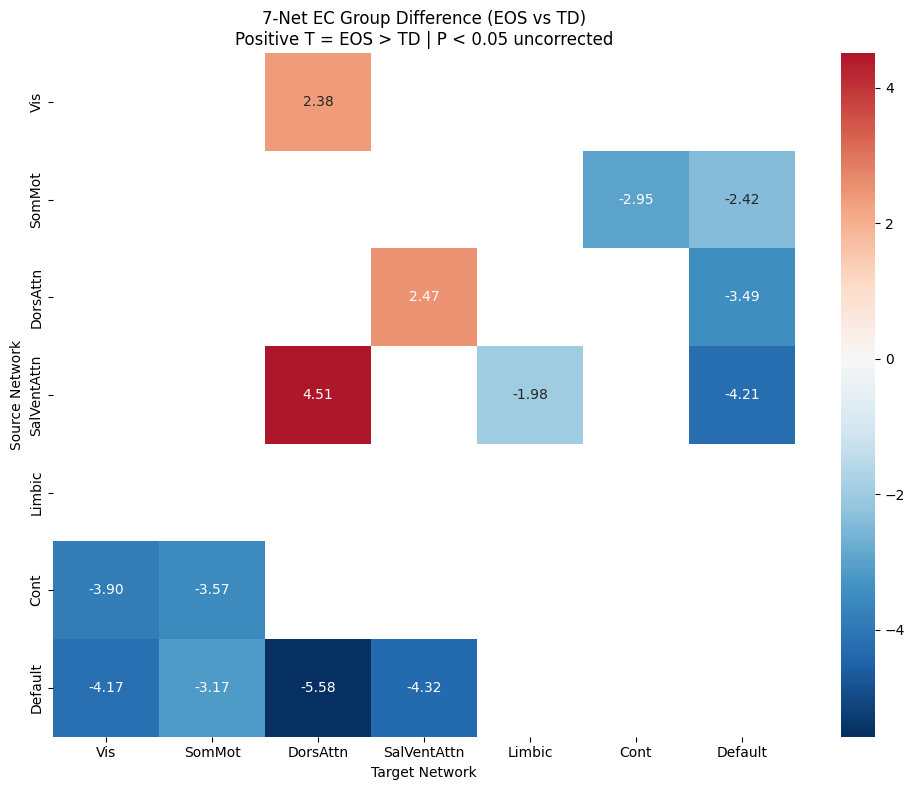

In [3]:
import os
import numpy as np
import scipy.io as sio
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. 参数与路径 ---
NET_EC_DIR = os.path.join(RES_BASE_DIR, "Net_EC_Results")
# 假设你已经有了 master_df 或类似的协变量表
master_data_path = os.path.join(RES_BASE_DIR, "Master_Data_after_excluding.csv")

# 加载被试信息
df = pd.read_csv(master_data_path)
# 确保只分析那些 Passed 的被试（即 NET_EC_DIR 里有文件的）
valid_ids = df[df['Status'] == 'Passed']['Sub_ID'].tolist()

# --- 2. 整合 3D 数据矩阵 (Subs x 7 x 7) ---
all_mats = []
final_subs = []

for sub_id in valid_ids:
    file_path = os.path.join(NET_EC_DIR, f"Net_EC_Sub_{sub_id}.mat")
    if os.path.exists(file_path):
        mat = sio.loadmat(file_path)['net_ec']
        all_mats.append(mat)
        final_subs.append(sub_id)

all_mats = np.array(all_mats) # 形状: (N_valid, 7, 7)
n_valid = len(final_subs)

# 过滤 df 以匹配最终参与统计的被试
df_stats = df[df['Sub_ID'].isin(final_subs)].copy()
# 确保顺序一致
df_stats['Sub_ID'] = df_stats['Sub_ID'].astype('category')
df_stats['Sub_ID'] = df_stats['Sub_ID'].cat.set_categories(final_subs)
df_stats = df_stats.sort_values('Sub_ID')

# --- 3. 逐条边进行统计检验 (GLM: EC ~ Group + Age + Gender + FD) ---
t_map = np.zeros((7, 7))
p_map = np.ones((7, 7))

# 定义网络标签
net_labels = ['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']

for i in range(7):
    for j in range(7):
        if i == j: continue # 跳过自反馈
        
        # 提取当前边的所有被试数值
        edge_values = all_mats[:, i, j]
        
        # 构建回归模型
        # y = EC, X = [Group, Age, Gender, MeanFD, Constant]
        Y = edge_values
        X = df_stats[['Group', 'Age', 'Gender', 'MeanFD']]
        X = sm.add_constant(X)
        
        model = sm.OLS(Y, X).fit()
        
        # 提取 Group 列的 t 值和 p 值 (假设 Group 列索引为 'Group')
        t_map[i, j] = model.tvalues['Group']
        p_map[i, j] = model.pvalues['Group']

# --- 4. 可视化差异矩阵 (T-map) ---
plt.figure(figsize=(10, 8))
# 掩盖 p > 0.05 的不显著边 (可选)
mask = p_map > 0.05 

sns.heatmap(t_map, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
            xticklabels=net_labels, yticklabels=net_labels,
            mask=mask) # 只显示显著的 T 值

plt.title("7-Net EC Group Difference (EOS vs TD)\nPositive T = EOS > TD | P < 0.05 uncorrected")
plt.xlabel("Target Network")
plt.ylabel("Source Network")
plt.tight_layout()
plt.show()

# --- 5. 保存统计结果 ---
sio.savemat(os.path.join(RES_BASE_DIR, "7Net_Stats_Result.mat"), {
    't_map': t_map,
    'p_map': p_map,
    'net_labels': net_labels
})

# Stats analysis (Gemini version 2.0)

2026-02-08 17:50:26,773 [INFO] 正在执行协变量回归...


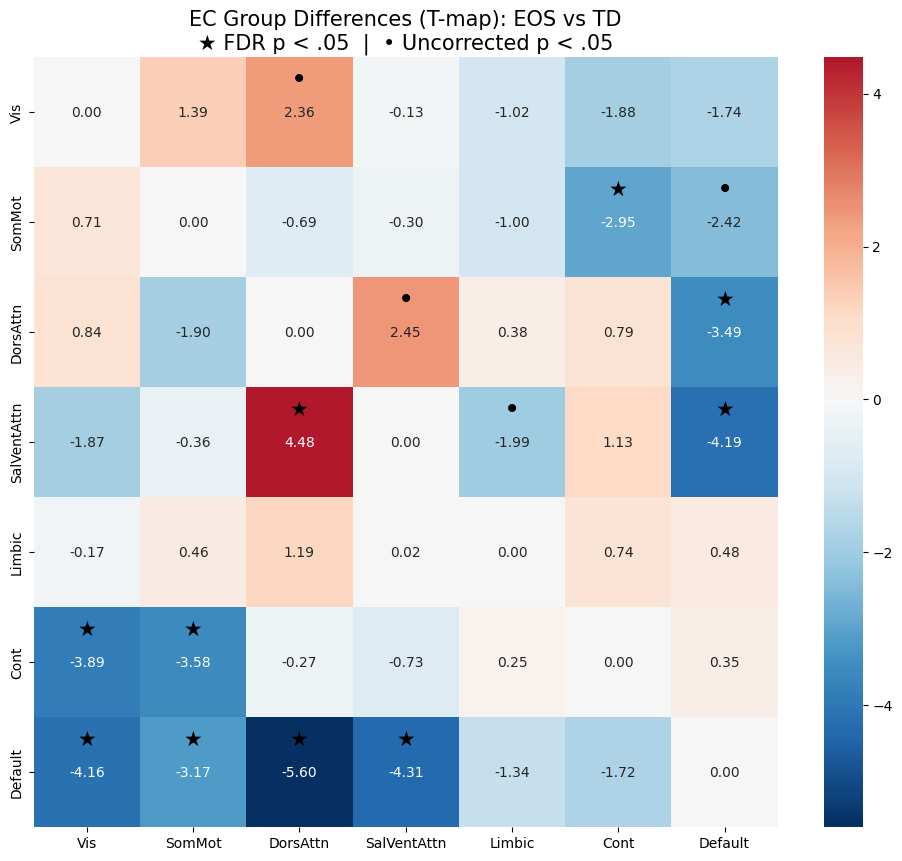

2026-02-08 17:50:27,346 [INFO] 分析完成！结果已存至: F:\NPI_result_2_7\Stats_Results


In [4]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import logging

# --- 1. 环境与路径配置 ---
RES_BASE_DIR = r"F:\NPI_result_2_7"
NET_EC_DIR = os.path.join(RES_BASE_DIR, "Net_EC_Results")
MASTER_DATA_PATH = os.path.join(RES_BASE_DIR, "Master_Data_Full_177_with_EC.csv")
STATS_DIR = os.path.join(RES_BASE_DIR, "Stats_Results")
os.makedirs(STATS_DIR, exist_ok=True)

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

network_names = ['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']

# --- 2. 加载数据并筛选 Passed 被试 ---
df = pd.read_csv(MASTER_DATA_PATH)
df_valid = df[df['Status'] == 'Passed'].copy().reset_index(drop=True)
valid_ids = df_valid['Sub_ID'].tolist()

def load_all_mats(id_list):
    mats = []
    for sub_id in id_list:
        path = os.path.join(NET_EC_DIR, f"Net_EC_Sub_{sub_id}.mat")
        if os.path.exists(path):
            mats.append(sio.loadmat(path)['net_ec'])
        else:
            logging.error(f"找不到被试 {sub_id} 的文件")
    return np.array(mats)

all_ec_raw = load_all_mats(valid_ids) # (N, 7, 7)
n_subs = all_ec_raw.shape[0]

# --- 3. 协变量回归 (Residualization) ---
def regress_cov_python(data_mats, covariates_df):
    """
    对 7x7 矩阵的每一条边回归掉协变量，并保留均值(残差化)
    """
    n, r, c = data_mats.shape
    cleaned_mats = np.zeros_like(data_mats)
    
    # 准备回归自变量: Age, Gender, MeanFD + Constant
    X = covariates_df[['Age', 'Gender', 'MeanFD']]
    X = sm.add_constant(X)
    
    logging.info("正在执行协变量回归...")
    for i in range(r):
        for j in range(c):
            if i == j: continue
            y = data_mats[:, i, j]
            model = sm.OLS(y, X).fit()
            # 我们取残差 + 原数据的均值，保持数值的可解释性
            cleaned_mats[:, i, j] = model.resid + y.mean()
    return cleaned_mats

# 执行回归
covars = df_valid[['Age', 'Gender', 'MeanFD']]
all_ec_regressed = regress_cov_python(all_ec_raw, covars)

# --- 4. 统计检验 (T-Test) ---
eos_mask = df_valid['Group'] == 1
td_mask = df_valid['Group'] == 0

t_stats = np.zeros((7, 7))
p_values = np.ones((7, 7))

for i in range(7):
    for j in range(7):
        if i == j: continue
        # 使用回归后的数据做 T 检验
        eos_vec = all_ec_regressed[eos_mask, i, j]
        td_vec = all_ec_regressed[td_mask, i, j]
        
        t_res, p_res = stats.ttest_ind(eos_vec, td_vec, equal_var=False)
        t_stats[i, j] = t_res
        p_values[i, j] = p_res

# --- 5. FDR 校正 ---
valid_mask = ~np.eye(7, dtype=bool)
p_to_correct = p_values[valid_mask]
reject, p_fdr_vec = multipletests(p_to_correct, method='fdr_bh')[:2]

p_fdr_matrix = np.full((7, 7), np.nan)
p_fdr_matrix[valid_mask] = p_fdr_vec

# --- 6. 可视化 ---
plt.figure(figsize=(12, 10))
sns.heatmap(t_stats, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
            xticklabels=network_names, yticklabels=network_names)

# 标记显著性
for i in range(7):
    for j in range(7):
        if i == j: continue
        # FDR 显著打大星
        if p_fdr_matrix[i, j] < 0.05:
            plt.text(j + 0.5, i + 0.2, '★', ha='center', va='center', color='black', fontsize=15)
        # 原始 P 显著打小点
        elif p_values[i, j] < 0.05:
            plt.text(j + 0.5, i + 0.2, '•', ha='center', va='center', color='black', fontsize=20)

plt.title('EC Group Differences (T-map): EOS vs TD\n★ FDR p < .05  |  • Uncorrected p < .05', fontsize=15)
plt.savefig(os.path.join(STATS_DIR, "EC_Group_Diff_TMap.png"), dpi=300)
plt.show()

# --- 7. 保存结果汇总 ---
res_list = []
for i in range(7):
    for j in range(7):
        if i == j: continue
        res_list.append({
            'Edge': f"{network_names[i]}_to_{network_names[j]}",
            'T_stat': t_stats[i, j],
            'P_uncorr': p_values[i, j],
            'P_FDR': p_fdr_matrix[i, j],
            'EOS_Mean': all_ec_regressed[eos_mask, i, j].mean(),
            'TD_Mean': all_ec_regressed[td_mask, i, j].mean(),
            'Significant_FDR': "YES" if p_fdr_matrix[i, j] < 0.05 else "NO"
        })

summary_df = pd.DataFrame(res_list)
summary_df.to_csv(os.path.join(STATS_DIR, "EC_Stat_Summary.csv"), index=False)

# 保存清洗后的 EC 数据方便后续中介分析使用
np.save(os.path.join(STATS_DIR, "EC_Regressed_All_Passed.npy"), all_ec_regressed)

logging.info(f"分析完成！结果已存至: {STATS_DIR}")

# Stats analysis (Gemini version 1.0)

## * Exclude subs id

In [ ]:
# ====== 1. Load files =======
# with open(json_path, 'r') as f:
#     status_data = json.load(f)

# valid_ids = status_data["valid_ids"]
#  ====== 2. Defined directly ======
excluded_ids = [131]
valid_ids = [i for i in range(1, 178) if i not in excluded_ids]

eos_ids = [idx for idx in valid_ids if 1 <= idx <= 86]
td_ids = [idx for idx in valid_ids if 87 <= idx <= 177]


### * Load regressors (excluded)

In [3]:

raw_regressors = sio.loadmat("Regressors177_3.mat")['Regressors']
# Exclude subs who train not successfully
current_regressors = raw_regressors[[idx - 1 for idx in valid_ids], :]

### Load EC and save (not excluded) for Mediation part!

In [ ]:
import numpy as np
import scipy.io as sio
import os

# --- 1. 初始化全量矩阵 (177人, 49个特征) ---
# 即使文件不存在，位置也要留出来，填充为 NaN
all_EC_net_full = np.full((177, 49), np.nan)

# --- 2. 遍历 1 到 177，精准填入数据 ---
for sub_id in range(1, 178):
    # 这里的 save_dir 是你存放 Net_EC_Sub_*.mat 的目录
    path = os.path.join(RES_BASE_DIR, f"Net_EC_Sub_{sub_id}.mat")
    
    if os.path.exists(path):
        mat = sio.loadmat(path)['net_ec']
        # 展平并填入对应行（sub_id 1 对应索引 0）
        all_EC_net_full[sub_id - 1, :] = mat.flatten()
    else:
        # sub37 就会在这里被标记
        print(f"提示: 被试 {sub_id} 的文件不存在或已排除，该行保留为 NaN")

# --- 3. 保存全量矩阵 ---
# 建议保存为 npy 格式，读取极快
full_save_path = os.path.join(stats_results_dir, "EC_Raw_Full_177.npy")
np.save(full_save_path, all_EC_net_full)

# 同时保存一份 mat 格式，方便你以后回 MATLAB 检查
sio.savemat(os.path.join(stats_results_dir, "EC_Raw_Full_177.mat"), {"all_EC_net_full": all_EC_net_full})

logging.info(f"177人全量 EC 矩阵已保存至: {full_save_path}")

2026-02-06 12:01:40,862 [INFO] 177人全量 EC 矩阵已保存至: F:\NPI_results\bs_50\reidx\stats_result\EC_Raw_Full_177.npy


提示: 被试 37 的文件不存在或已排除，该行保留为 NaN


### * Load EC data (excluded)

In [ ]:
'''All subs excluding excluded sub'''
all_EC_net_mats = []
for sub_id in valid_ids:
    path = os.path.join(RES_BASE_DIR, f"Net_EC_Sub_{sub_id}.mat")
    if os.path.exists(path):
        mat = sio.loadmat(path)['net_ec']
        all_EC_net_mats.append(mat.flatten())
    else:
        print(f"警告: 找不到被试 {sub_id} 的文件")

all_EC_net_mats = np.array(all_EC_net_mats) # 形状: (176, 49)

## Regressing

### * Regressing function def

In [8]:
'''regress funcion def'''
import numpy as np
import pandas as pd
import statsmodels.api as sm

def regress_cov_python(data, regressors):
    """
    去除数据中的协变量影响（回归去噪）
    
    参数:
    data: 2D array, 维度为 (被试数, 特征数)，如 (177, 49)
    regressors: 2D array, 维度为 (被试数, 协变量数)，如 (177, 3) 包含年龄、性别、头动
    
    返回:
    datat: 校正后的残差数据，维度与 data 一致
    """
    # 如果没有协变量，直接返回原数据
    if regressors is None or len(regressors) == 0:
        return data
    
    num_subjects, num_features = data.shape
    datat = np.zeros_like(data)
    
    # 给协变量矩阵加上常数项（截距项 Intercept）
    # 这一步非常重要，相当于 MATLAB glmfit 默认包含的常数项
    X = sm.add_constant(regressors) 
    
    for i in range(num_features):
        y = data[:, i]
        
        # 检查是否有 NaN
        if not np.all(np.isnan(y)):
            # 建立线性模型
            model = sm.OLS(y, X).fit()
            
            # 计算残差： 原始值 - (截距 + 协变量 * 系数)
            # model.resid 直接就是我们要的“去噪后信号”
            datat[:, i] = model.resid
        else:
            datat[:, i] = y
            
    return datat

# --- 使用示例 ---
# 假设 mean_optimal_all 是你的 (177, 49) 矩阵
# 假设 Regressors 是你的 (177, 3) 协变量矩阵

# 1. 运行回归校正
# mean_optimal_all_rcov = regress_cov_python(mean_optimal_all, Regressors)

# 2. 如果你想把它变回 (177, 7, 7) 的形式进行后续 T 检验：
# eos_mats_rcov = mean_optimal_all_rcov[:86, :].reshape(-1, 7, 7)
# td_mats_rcov = mean_optimal_all_rcov[86:, :].reshape(-1, 7, 7)

### * Regressing for EC (raw) and save the EC (before regressing and after regressing)

In [ ]:
''' 保存未regress 和 regress 后的all subs EC 强度。'''


all_mats_rcov = regress_cov_python(all_EC_net_mats, current_regressors)


conn_names = []
for src in network_names:
    for tgt in network_names:
        conn_names.append(f"{src}_to_{tgt}")

subject_info = pd.DataFrame({'Sub_ID': valid_ids})

# 原始数据表格 (Before Regression)
df_before = pd.concat([subject_info, pd.DataFrame(all_EC_net_mats, columns=conn_names)], axis=1)

# 回归校正后数据表格 (After Regression)
df_after = pd.concat([subject_info, pd.DataFrame(all_mats_rcov, columns=conn_names)], axis=1)

# --- 3. 保存文件 ---
save_path_before = os.path.join(stats_results_dir, "EC_All_Subjects_Raw.csv")
save_path_after = os.path.join(stats_results_dir, "EC_All_Subjects_Regressed.csv")

df_before.to_csv(save_path_before, index=False)
df_after.to_csv(save_path_after, index=False)

logging.info(f"数据已保存！\n原始文件：{save_path_before}\n校正后文件：{save_path_after}")


2026-02-06 10:32:38,325 [INFO] 数据已保存！
原始文件：F:\NPI_results\bs_50\reidx\stats_result\EC_All_Subjects_Raw.csv
校正后文件：F:\NPI_results\bs_50\reidx\stats_result\EC_All_Subjects_Regressed.csv


## Statistical testing (EC Raw)

### t-test

In [ ]:

def get_group_matrices(id_list):
    matrices = []
    for sub_id in id_list:
        path = os.path.join(RES_BASE_DIR, f"Net_EC_Sub_{sub_id}.mat")
        if os.path.exists(path):
            matrices.append(sio.loadmat(path)['net_ec'])
        else:
            logging.info(f"Can't find sub {sub_id}'s EC file!")
    return np.array(matrices) # 返回形状: (Subject_Num, 7, 7)



eos_mats = get_group_matrices(eos_ids)
td_mats = get_group_matrices(td_ids)

# --- 2. 逐点 T 检验 (Element-wise T-test) ---
t_stats = np.zeros((7, 7))
p_values = np.zeros((7, 7))

for i in range(7):
    for j in range(7):
        # 提取两组被试在同一个位置 (i, j) 的连接值
        eos_vec = eos_mats[:, i, j]
        td_vec = td_mats[:, i, j]
        
        # 执行独立样本 T 检验 (假设方差不齐使用 Welch's t-test)
        t_res, p_res = stats.ttest_ind(eos_vec, td_vec, equal_var=False)
        t_stats[i, j] = t_res
        p_values[i, j] = p_res

        


### FDR

In [13]:
# (废弃)--- 3. 多重比较校正 (FDR Correction) ---
    # 将 7x7 的 p 值展平进行校正，然后再折叠回来
    # p_flat = p_values.flatten()
    # reject, p_fdr = multipletests(p_flat, method='fdr_bh')[:2]
    # p_fdr_matrix = p_fdr.reshape(7, 7)

#
# --- 3. 多重比较校正 (FDR Correction) ---
valid_mask = (1 - np.eye(7)).astype(bool)

# 2. 提取非对角线的 P 值（得到一个长度为 42 的向量）
p_to_correct = p_values[valid_mask]

# 3. 检查是否有 NaN（以防万一），只对非 NaN 的值进行校正
nan_map = np.isnan(p_to_correct)
p_valid_only = p_to_correct[~nan_map]

# 4. 执行 FDR 校正 (只针对有效的数据点)
reject_valid, p_fdr_valid = multipletests(p_valid_only, method='fdr_bh')[:2]

# 5. 还原回 7x7 矩阵
# 先创建一个全为 NaN 的 7x7 矩阵
p_fdr_matrix = np.full((7, 7), np.nan)

# 把校正后的结果填回到有效位置
# 注意：这里要确保填回的逻辑与提取时一致
p_fdr_matrix[valid_mask] = p_fdr_valid # 先初始化有效位置为 nan



### 保存统计值 + 可视化 
p_fdr<0.05 标*；
p < 0.05 标.

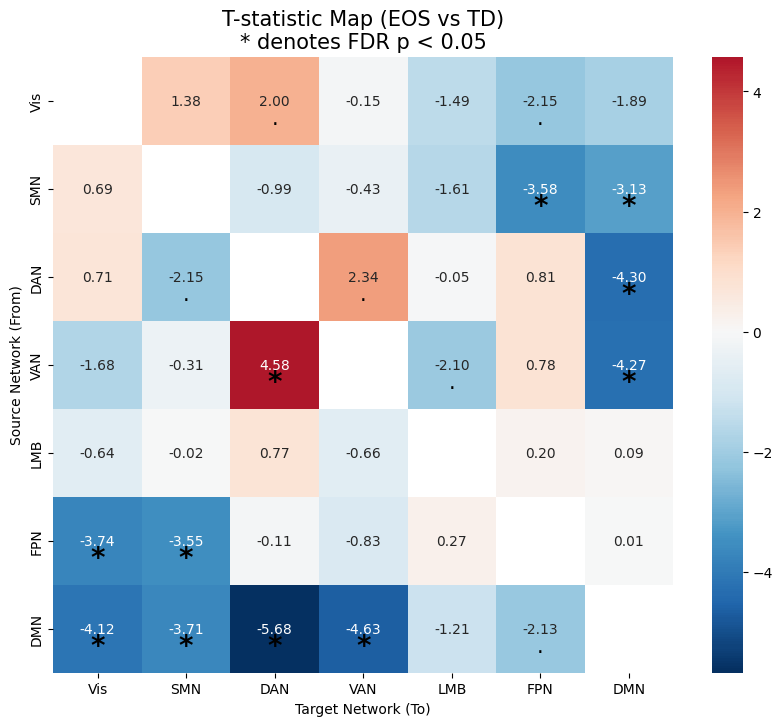

2026-02-06 10:36:32,439 [INFO] 统计分析完成！显著差异连接已存入 CSV。


In [ ]:


sig_mask = p_fdr_matrix < 0.05 # 显著性掩码

# --- 4. 统计结果可视化 ---
plt.figure(figsize=(10, 8))

# 绘制 T 值热图（展示差异的方向：红色代表 EOS > TD, 蓝色代表 EOS < TD）
sns.heatmap(t_stats, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
            xticklabels=network_names, yticklabels=network_names)

# 在显著的格子上打星号 (*)
for i in range(7):
    for j in range(7):
        if p_fdr_matrix[i, j] < 0.05:
            plt.text(j + 0.5, i + 0.7, '*', ha='center', va='center', color='black', fontsize=20, fontweight='bold')
        elif p_values[i, j] < 0.05: # 如果FDR太严，可以退而求其次看原始P值（打点标记）
            plt.text(j + 0.5, i + 0.7, '.', ha='center', va='center', color='black', fontsize=15)

plt.title('T-statistic Map (EOS vs TD)\n* denotes FDR p < 0.05', fontsize=15)
plt.xlabel('Target Network (To)')
plt.ylabel('Source Network (From)')
plt.show()

# --- 5. 保存统计汇总报告 ---
sig_indices = np.where(sig_mask)
results = []
for i, j in zip(sig_indices[0], sig_indices[1]):
    results.append({
        'Source': network_names[i],
        'Target': network_names[j],
        'T_stat': t_stats[i, j],
        'P_uncorrected': p_values[i, j],
        'P_FDR': p_fdr_matrix[i, j],
        'EOS_Mean': np.mean(eos_mats[:, i, j]),
        'TD_Mean': np.mean(td_mats[:, i, j])
    })

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(stats_results_dir, "EC_Stat_Raw.csv"), index=False)
logging.info("统计分析完成！显著差异连接已存入 CSV。")

### visulization for Group distribution

C:\Users\Liang\AppData\Local\Temp\ipykernel_12496\3905146581.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=conn, data=df_plot, palette='Set2', width=0.4, showfliers=False)


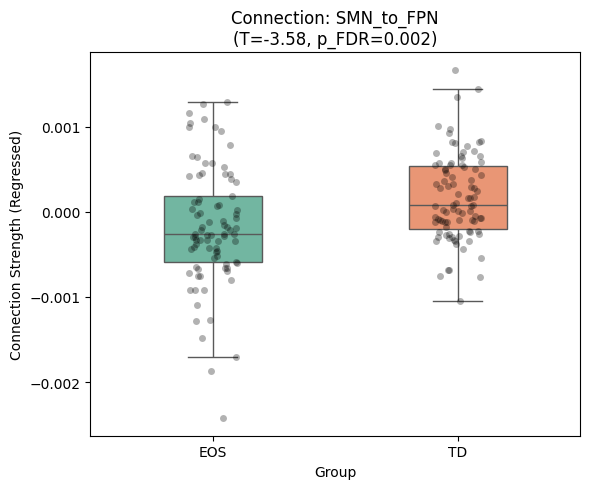

C:\Users\Liang\AppData\Local\Temp\ipykernel_12496\3905146581.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=conn, data=df_plot, palette='Set2', width=0.4, showfliers=False)


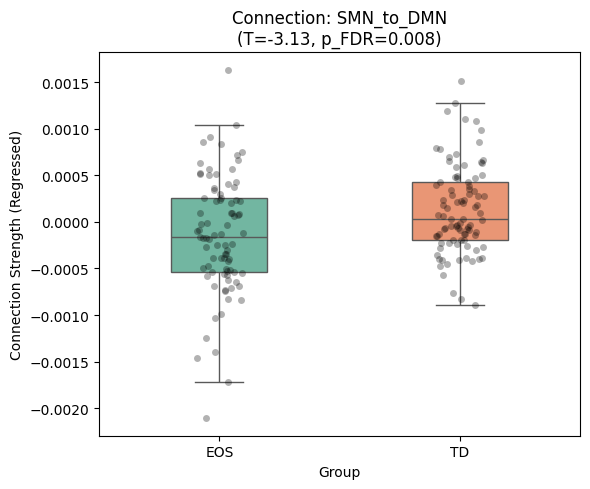

C:\Users\Liang\AppData\Local\Temp\ipykernel_12496\3905146581.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=conn, data=df_plot, palette='Set2', width=0.4, showfliers=False)


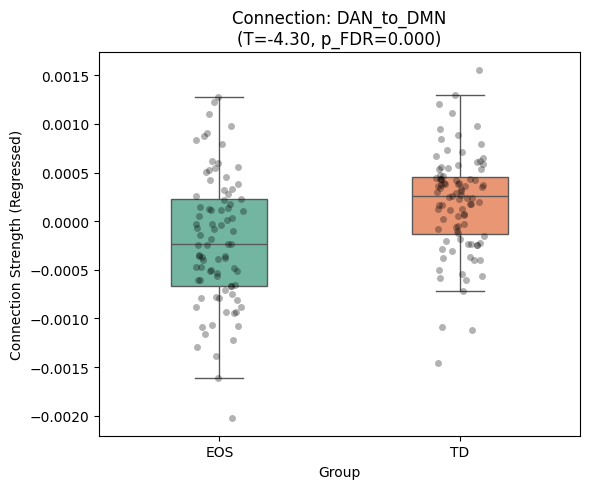

C:\Users\Liang\AppData\Local\Temp\ipykernel_12496\3905146581.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=conn, data=df_plot, palette='Set2', width=0.4, showfliers=False)


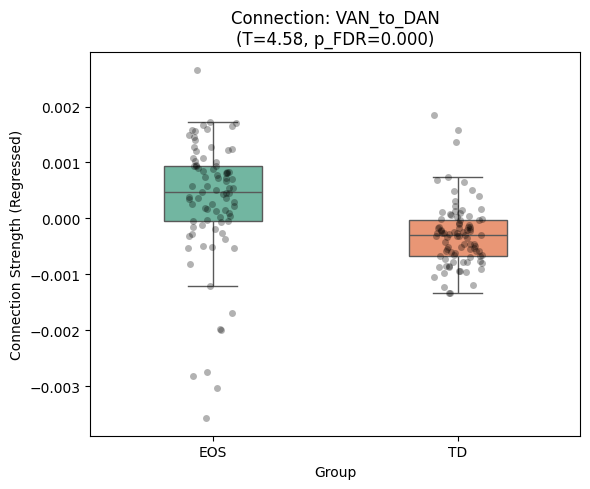

C:\Users\Liang\AppData\Local\Temp\ipykernel_12496\3905146581.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=conn, data=df_plot, palette='Set2', width=0.4, showfliers=False)


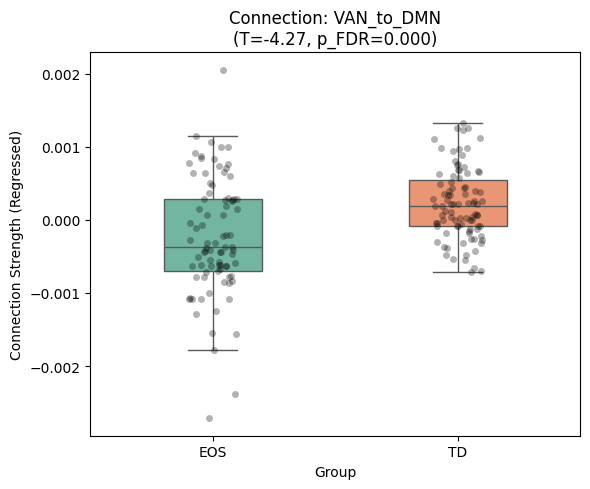

C:\Users\Liang\AppData\Local\Temp\ipykernel_12496\3905146581.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=conn, data=df_plot, palette='Set2', width=0.4, showfliers=False)


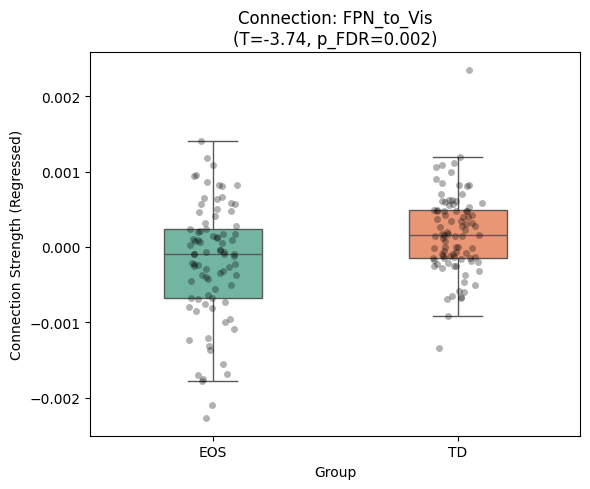

C:\Users\Liang\AppData\Local\Temp\ipykernel_12496\3905146581.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=conn, data=df_plot, palette='Set2', width=0.4, showfliers=False)


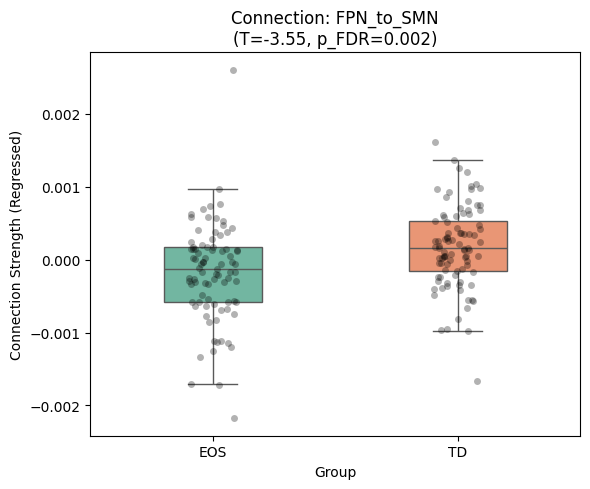

C:\Users\Liang\AppData\Local\Temp\ipykernel_12496\3905146581.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=conn, data=df_plot, palette='Set2', width=0.4, showfliers=False)


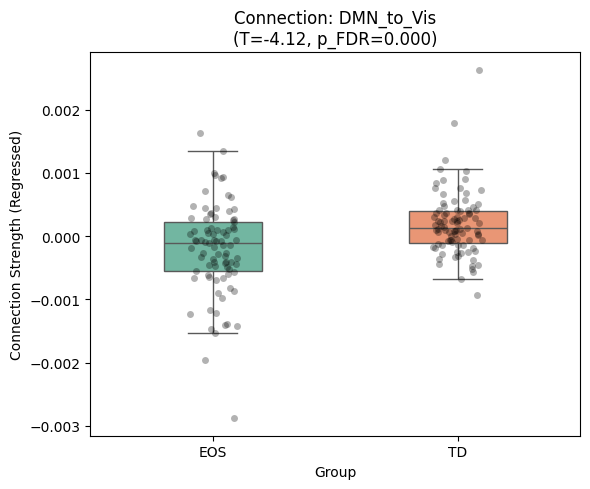

C:\Users\Liang\AppData\Local\Temp\ipykernel_12496\3905146581.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=conn, data=df_plot, palette='Set2', width=0.4, showfliers=False)


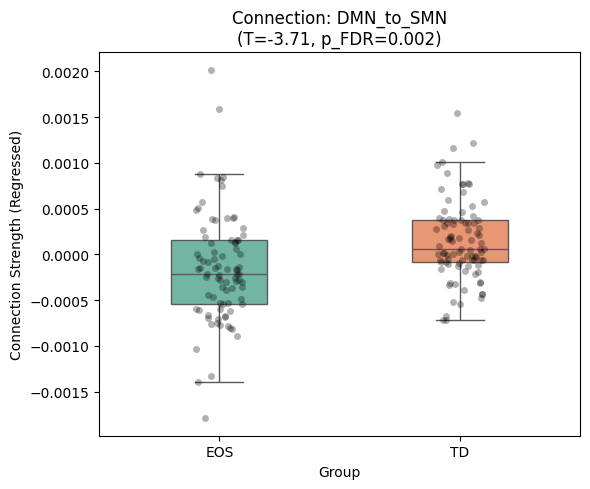

C:\Users\Liang\AppData\Local\Temp\ipykernel_12496\3905146581.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=conn, data=df_plot, palette='Set2', width=0.4, showfliers=False)


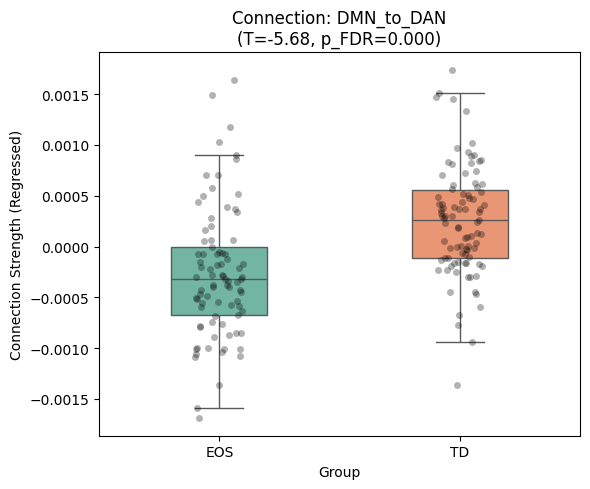

C:\Users\Liang\AppData\Local\Temp\ipykernel_12496\3905146581.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=conn, data=df_plot, palette='Set2', width=0.4, showfliers=False)


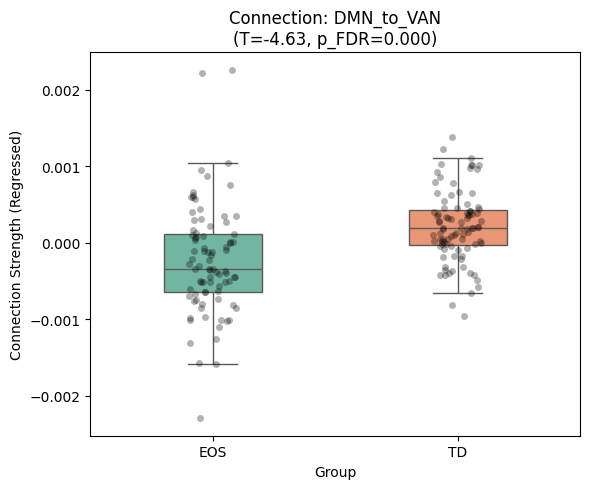

显著连接的分布图已全部生成并保存至 F:\NPI_results\bs_50\reidx\stats_result


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. 准备绘图数据 ---
# 假设你已经有了 df_after (包含 Sub_ID 和 49个特征) 
# 我们需要给 df_after 加上 Group 标签以便绘图
df_plot = df_after.copy()
df_plot['Group'] = ['EOS' if idx in eos_ids else 'TD' for idx in valid_ids]

# 获取所有显著的连接名称 (从刚才的 sig_df 中提取)
sig_conns = results_df['Source'] + "_to_" + results_df['Target']

# --- 2. 循环绘制显著连接的分布图 ---
for conn in sig_conns:
    plt.figure(figsize=(6, 5))
    
    # 绘制箱线图：展示中位数和四分位距
    sns.boxplot(x='Group', y=conn, data=df_plot, palette='Set2', width=0.4, showfliers=False)
    
    # 叠加散点图（Jitter）：展示每一个被试的真实分布
    sns.stripplot(x='Group', y=conn, data=df_plot, color='black', alpha=0.3, jitter=True)
    
    # 润色图表
    t_val = results_df.loc[(results_df['Source'] + "_to_" + results_df['Target']) == conn, 'T_stat'].values[0]
    p_fdr = results_df.loc[(results_df['Source'] + "_to_" + results_df['Target']) == conn, 'P_FDR'].values[0]
    
    plt.title(f'Connection: {conn}\n(T={t_val:.2f}, p_FDR={p_fdr:.3f})', fontsize=12)
    plt.xlabel('Group', fontsize=10)
    plt.ylabel('Connection Strength (Regressed)', fontsize=10)
    
    # 保存图片
    plt.tight_layout()
    plt.savefig(os.path.join(stats_results_dir, f"Dist_{conn}.png"), dpi=300)
    plt.show()

logging.info(f"显著连接的分布图已全部生成并保存至 {stats_results_dir}")

## Statistical testing (excited EC)

## Statistical testing (inhibited EC)